In [ ]:
print("hello")

hello


In [1]:
# Step 1: Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [5]:
# Step 2: Load Dataset from CSV File
url = "https://raw.githubusercontent.com/rajendra0968jangid/ml-project-1/main/employee_salary_data.csv"
df = pd.read_csv(url)

print("Dataset Preview:\n")
print(df.head())

print("\nDataset Info:\n")
print(df.info())

print("\nMissing Values:\n")
print(df.isnull().sum())

Dataset Preview:

   Experience  Education_Level  Skill_Score  Interview_Score  Salary
0           1                1           60               65   25000
1           2                2           70               72   32000
2           3                2           75               78   38000
3           4                3           80               85   45000
4           5                3           85               88   52000

Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Experience       10 non-null     int64
 1   Education_Level  10 non-null     int64
 2   Skill_Score      10 non-null     int64
 3   Interview_Score  10 non-null     int64
 4   Salary           10 non-null     int64
dtypes: int64(5)
memory usage: 532.0 bytes
None

Missing Values:

Experience         0
Education_Level    0
Skill_Score        0
Interview_Scor

In [6]:
# Step 3: Handle Missing Values (if any)
df = df.dropna()

In [7]:
# Step 4: Define Input and Output Variables
X = df[['Experience','Education_Level','Skill_Score','Interview_Score']]
Y = df[['Salary']]


In [8]:
# Step 5: Train-Test Split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [9]:
# Step 6: Create and Train Model
model = LinearRegression()
model.fit(X_train,Y_train)

LinearRegression()

In [10]:
# Step 7: Prediction
Y_pred = model.predict(X_test)

print("\nActual Salary:")
print(Y_test.values)

print("\nPredicted Salary:")
print(Y_pred)


Actual Salary:
[[82000]
 [32000]]

Predicted Salary:
[[82668.55817273]
 [31029.5503212 ]]


In [14]:
# Step 8: Model Evaluation
mae = mean_absolute_error(Y_test,Y_pred)
mse = mean_squared_error(Y_test,Y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test,Y_pred)

print("\nModel Performance:\n")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)


Model Performance:

MAE : 819.5039257673016
MSE : 694371.3047068832
RMSE : 833.2894483352608
R2 Score : 0.998889005912469


In [16]:
# Step 9: Feature Importance (Coefficients)
print("\nModel Coefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature}: {coef}")

print("\nIntercept:", model.intercept_)


Model Coefficients:
Experience: [8023.44753747  413.41898644 -244.3254818    31.97715917]

Intercept: [28956.2455389]


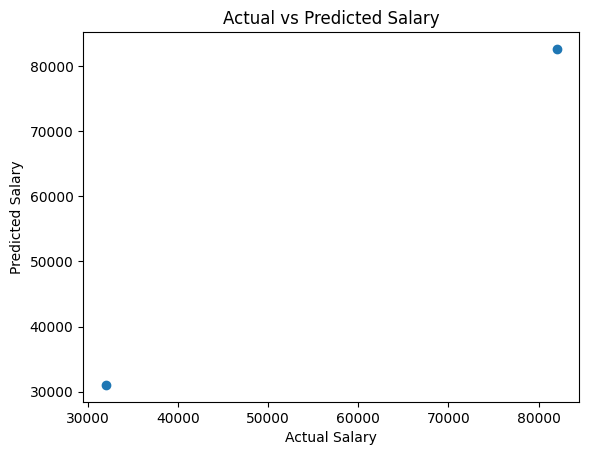

In [17]:
# Step 10: Visualization (Actual vs Predicted)
plt.scatter(Y_test,Y_pred)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")
plt.show()

In [20]:
# Step 11: Predict Salary for New Employee
new_employee = pd.DataFrame({'Experience':[5],'Education_Level':[3],'Skill_Score':[85],'Interview_Score':[90]})

predicted_salary = model.predict(new_employee)

print("\nPredicted Salary for New Employee:")
print(predicted_salary[0])



Predicted Salary for New Employee:
[52424.01855817]
